# TabPFN for Uplift Modeling with Meta-Learners

This notebook evaluates whether TabPFN can improve uplift modeling performance when used inside meta-learners (S-learner, T-learner, X-learner) compared to traditional models.

**Dataset**: IHDP (Infant Health and Development Program)

**Meta-learners to test**:
- **S-learner**: Single model predicting outcome with treatment as feature
- **T-learner**: Two separate models for treatment and control groups
- **X-learner**: Two-stage approach that imputes counterfactual outcomes and uses propensity-weighted CATE estimates
- **R-learner**
- **DR-Learner**

## 1. Setup and Imports

In [1]:
import numpy as np
import pandas as pd
from lightgbm import LGBMRegressor, LGBMClassifier
from sklearn.linear_model import LinearRegression, LogisticRegression
from tabpfn import TabPFNRegressor, TabPFNClassifier
import matplotlib.pyplot as plt
from econml.metalearners import SLearner, TLearner, XLearner
from econml.dml import NonParamDML
from econml.dr import LinearDRLearner
from sklearn.metrics import mean_squared_error
import warnings
import torch
import tabpfn
try:
    from causalpfn import CATEEstimator
except ImportError:
    print("CausalPFN not installed. Please install with: pip install causalpfn")
print(tabpfn.__version__)

# Detect device
if torch.cuda.is_available():
    device = 'cuda'
elif torch.backends.mps.is_available():
    device = 'mps'
else:
    device = 'cpu'
print(f"Using device: {device}")

# Set random seed for reproducibility
np.random.seed(42)

# Suppress warnings
warnings.filterwarnings("ignore")

/opt/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


6.2.0
Using device: mps


## 2. Define Models, Tuning, and Metrics

We define LightGBM hyperparameter tuning functions (using `RandomizedSearchCV`) and evaluation metrics. LightGBM is tuned **once per dataset** — the best hyperparameters are then reused across all meta-learners for that dataset.

In [12]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, StratifiedKFold, KFold
from sklearn.metrics import mean_squared_error
import numpy as np

# ── Paper grid (Machlanski et al. 2023, Table 2) ─────────────────────────────
# n_estimators fixed at 1000 (as in paper), only max_depth + reg_lambda searched
LGBM_GRID_PAPER = {
    'max_depth':  [5, 6, 7, 8, 9, 10],
    'reg_lambda': [0, 0.1, 1, 5, 10],
}

# ── Strong grid (fair, broader baseline) ─────────────────────────────────────
LGBM_GRID_STRONG = {
    'max_depth':         [3, 5, 7, 9],
    'num_leaves':        [15, 31, 63, 127],
    'learning_rate':     [0.01, 0.05, 0.1],
    'min_child_samples': [5, 10, 20, 50],
    'subsample':         [0.7, 0.85, 1.0],
    'colsample_bytree':  [0.7, 0.85, 1.0],
    'reg_lambda':        [0, 0.1, 1, 10],
}
N_ITER_STRONG = 15  # RandomizedSearchCV draws


# ── Core tuner (pooled data — for S, R, DR learners) ─────────────────────────
def _tune_reg(X, y, stratify, grid, n_iter=None, n_estimators_search=200, 
              n_estimators_final=1000, seed=42):
    # Search with fewer trees — faster CV
    base = LGBMRegressor(n_estimators=n_estimators_search, random_state=seed, verbose=-1)
    cv = list(StratifiedKFold(n_splits=3, shuffle=True, random_state=seed).split(X, stratify))
    Search = RandomizedSearchCV if n_iter else GridSearchCV
    kw = dict(n_iter=n_iter, random_state=seed) if n_iter else {}
    search = Search(base, grid, scoring='neg_mean_squared_error', cv=cv, n_jobs=-1, **kw)
    search.fit(X, y)
    
    # Refit best params with full number of trees
    best_params = search.best_params_
    final_model = LGBMRegressor(n_estimators=n_estimators_final, random_state=seed, 
                                 verbose=-1, **best_params)
    final_model.fit(X, y)
    return final_model
def _tune_cls(X, t, grid, n_iter=None, n_estimators_search=200,
              n_estimators_final=1000, seed=42):
    base = LGBMClassifier(n_estimators=n_estimators_search, random_state=seed, verbose=-1)
    cv = list(StratifiedKFold(n_splits=3, shuffle=True, random_state=seed).split(X, t))
    Search = RandomizedSearchCV if n_iter else GridSearchCV
    kw = dict(n_iter=n_iter, random_state=seed) if n_iter else {}
    search = Search(base, grid, scoring='neg_log_loss', cv=cv, n_jobs=-1, **kw)
    search.fit(X, t)
    
    best_params = search.best_params_
    final_model = LGBMClassifier(n_estimators=n_estimators_final, random_state=seed,
                                  verbose=-1, **best_params)
    final_model.fit(X, t)
    return final_model

def _tune_reg_arm(X_arm, y_arm, grid, n_iter=None, n_estimators_search=200,
                  n_estimators_final=1000, seed=42):
    n_splits = min(3, max(2, len(y_arm) // 20))
    base = LGBMRegressor(n_estimators=n_estimators_search, random_state=seed, verbose=-1)
    cv = list(KFold(n_splits=n_splits, shuffle=True, random_state=seed).split(X_arm))
    Search = RandomizedSearchCV if n_iter else GridSearchCV
    kw = dict(n_iter=n_iter, random_state=seed) if n_iter else {}
    search = Search(base, grid, scoring='neg_mean_squared_error', cv=cv, n_jobs=-1, **kw)
    search.fit(X_arm, y_arm)
    
    best_params = search.best_params_
    final_model = LGBMRegressor(n_estimators=n_estimators_final, random_state=seed,
                                 verbose=-1, **best_params)
    final_model.fit(X_arm, y_arm)
    return final_model



def _extract(model, grid):
    """Pull only the searched params (+ n_estimators) out of a fitted estimator."""
    p = model.get_params()
    keys = set(grid.keys()) | {'n_estimators'}
    return {k: p[k] for k in keys if k in p}

def make_reg(params, seed=42):
    return LGBMRegressor(random_state=seed, verbose=-1, **params)

def make_cls(params, seed=42):
    return LGBMClassifier(random_state=seed, verbose=-1, **params)


# ── Metric functions ──────────────────────────────────────────────────────────
def calculate_pehe(predicted_ite, true_ite):
    return np.sqrt(mean_squared_error(true_ite, predicted_ite))

def calculate_ate_error(predicted_ite, true_ite):
    return np.abs(predicted_ite.mean() - true_ite.mean())


## 3. Data Loading (IHDP 1-100)

We load 100 realizations of the IHDP dataset from local `.npz` files and store them for evaluation.

In [8]:
from collections import defaultdict

# Store results for all runs
# Structure: results[meta_learner][base_model][metric] = list of values
all_results = defaultdict(lambda: defaultdict(lambda: defaultdict(list)))

# Load IHDP data from local npz files (100 replications)
train_data = np.load('IHDP/ihdp_npci_1-100.train.npz')
test_data = np.load('IHDP/ihdp_npci_1-100.test.npz')

n_datasets = 100
processed_datasets = []
feature_names = [f"x{j}" for j in range(25)]

print(f"Loading {n_datasets} replications from local IHDP files...")

for i in range(n_datasets):
    X_train = pd.DataFrame(train_data['x'][:, :, i], columns=feature_names)
    T_train = train_data['t'][:, i]
    Y_train = train_data['yf'][:, i]
    mu0_train = train_data['mu0'][:, i]
    mu1_train = train_data['mu1'][:, i]

    X_test = pd.DataFrame(test_data['x'][:, :, i], columns=feature_names)
    T_test = test_data['t'][:, i]
    Y_test = test_data['yf'][:, i]
    mu0_test = test_data['mu0'][:, i]
    mu1_test = test_data['mu1'][:, i]

    true_ITE_test = mu1_test - mu0_test

    processed_datasets.append({
        'id': i + 1,
        'X_train': X_train,
        'X_test': X_test,
        'T_train': T_train,
        'T_test': T_test,
        'Y_train': Y_train,
        'Y_test': Y_test,
        'true_ITE_test': true_ITE_test
    })

print(f"Loaded {len(processed_datasets)} replications.")
print(f"Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}, Features: {X_train.shape[1]}")

Loading 100 replications from local IHDP files...
Loaded 100 replications.
Train size: 672, Test size: 75, Features: 25


## 4. Unified Meta-Learner Evaluation

We evaluate all five meta-learners (S, T, X, R, DR) in a single loop over the 100 IHDP replications. For each dataset, we tune LightGBM once for the outcome model (regressor) and once for the propensity model (classifier), then reuse those tuned models across all meta-learners. This avoids redundant tuning and ensures consistency.

In [13]:


print("Evaluating all meta-learners across 100 IHDP replications...\n")

for dataset in processed_datasets:
    i = dataset['id']
    print(f"Processing dataset {i}/100...", end='\r')

    X_train, X_test = dataset['X_train'], dataset['X_test']
    T_train          = dataset['T_train']
    Y_train          = dataset['Y_train']
    true_ITE_test    = dataset['true_ITE_test']

    # ── Arm splits (needed for T and X learner tuning) ───────────────────────
    ctrl = T_train == 0
    trt  = T_train == 1
    X_ctrl, Y_ctrl = X_train[ctrl], Y_train[ctrl]
    X_trt,  Y_trt  = X_train[trt],  Y_train[trt]

    # ── PAPER grid: tune pooled (S/R/DR) and per-arm (T/X) ──────────────────
    p_reg  = _extract(_tune_reg(X_train, Y_train, T_train, LGBM_GRID_PAPER), LGBM_GRID_PAPER)
    p_cls  = _extract(_tune_cls(X_train, T_train,          LGBM_GRID_PAPER), LGBM_GRID_PAPER)
    # ↓ T and X learner: tune separately on each arm
    p_ctrl = _extract(_tune_reg_arm(X_ctrl, Y_ctrl, LGBM_GRID_PAPER), LGBM_GRID_PAPER)
    p_trt  = _extract(_tune_reg_arm(X_trt,  Y_trt,  LGBM_GRID_PAPER), LGBM_GRID_PAPER)

    # ── STRONG grid: same structure ──────────────────────────────────────────
    s_reg  = _extract(_tune_reg(X_train, Y_train, T_train, LGBM_GRID_STRONG, N_ITER_STRONG), LGBM_GRID_STRONG)
    s_cls  = _extract(_tune_cls(X_train, T_train,          LGBM_GRID_STRONG, N_ITER_STRONG), LGBM_GRID_STRONG)
    # ↓ T and X learner: tune separately on each arm
    s_ctrl = _extract(_tune_reg_arm(X_ctrl, Y_ctrl, LGBM_GRID_STRONG, N_ITER_STRONG), LGBM_GRID_STRONG)
    s_trt  = _extract(_tune_reg_arm(X_trt,  Y_trt,  LGBM_GRID_STRONG, N_ITER_STRONG), LGBM_GRID_STRONG)

    # ── Model configs ────────────────────────────────────────────────────────
    base_model_configs = {
        'LinearRegression': {
            's_model':       LinearRegression(),
            't_models':      (LinearRegression(), LinearRegression()),
            'x_models':      (LinearRegression(), LinearRegression()),
            'x_propensity':  LogisticRegression(max_iter=1000, random_state=42),
            'r_model_y':     LinearRegression(),
            'r_model_t':     LogisticRegression(max_iter=1000, random_state=42),
            'r_model_final': LinearRegression(),
            'dr_regression': LinearRegression(),
            'dr_propensity': LogisticRegression(max_iter=1000, random_state=42),
        },
        'LightGBM_Paper': {
            's_model':       make_reg(p_reg,  42),
            # ↓ T and X: arm-specific params ← KEY CHANGE vs original
            't_models':      (make_reg(p_ctrl, 42), make_reg(p_trt, 43)),
            'x_models':      (make_reg(p_ctrl, 42), make_reg(p_trt, 43)),
            'x_propensity':  make_cls(p_cls,  44),
            'r_model_y':     make_reg(p_reg,  42),
            'r_model_t':     make_cls(p_cls,  43),
            'r_model_final': make_reg(p_reg,  44),
            'dr_regression': make_reg(p_reg,  42),
            'dr_propensity': make_cls(p_cls,  44),
        },
        'LightGBM_Strong': {
            's_model':       make_reg(s_reg,  42),
            # ↓ T and X: arm-specific params ← KEY CHANGE vs original
            't_models':      (make_reg(s_ctrl, 42), make_reg(s_trt, 43)),
            'x_models':      (make_reg(s_ctrl, 42), make_reg(s_trt, 43)),
            'x_propensity':  make_cls(s_cls,  44),
            'r_model_y':     make_reg(s_reg,  42),
            'r_model_t':     make_cls(s_cls,  43),
            'r_model_final': make_reg(s_reg,  44),
            'dr_regression': make_reg(s_reg,  42),
            'dr_propensity': make_cls(s_cls,  44),
        },
        'TabPFN': {
            's_model':       TabPFNRegressor(device=device),
            't_models':      (TabPFNRegressor(device=device), TabPFNRegressor(device=device)),
            'x_models':      (TabPFNRegressor(device=device), TabPFNRegressor(device=device)),
            'x_propensity':  TabPFNClassifier(device=device),
            'r_model_y':     TabPFNRegressor(device=device),
            'r_model_t':     TabPFNClassifier(device=device),
            'r_model_final': make_reg(s_reg, 44),  # residual-on-residual stage; LightGBM as before
            'dr_regression': TabPFNRegressor(device=device),
            'dr_propensity': TabPFNClassifier(device=device),
        },
    }


    for name, cfg in base_model_configs.items():
        # S-Learner
        s_learner = SLearner(overall_model=cfg['s_model'])
        s_learner.fit(Y_train, T_train, X=X_train)
        te = s_learner.effect(X_test)
        all_results['S'][name]['pehe'].append(calculate_pehe(te, true_ITE_test))
        all_results['S'][name]['ate_error'].append(calculate_ate_error(te, true_ITE_test))

        # T-Learner
        t_learner = TLearner(models=cfg['t_models'])
        t_learner.fit(Y_train, T_train, X=X_train)
        te = t_learner.effect(X_test)
        all_results['T'][name]['pehe'].append(calculate_pehe(te, true_ITE_test))
        all_results['T'][name]['ate_error'].append(calculate_ate_error(te, true_ITE_test))

        # X-Learner
        x_learner = XLearner(models=cfg['x_models'], propensity_model=cfg['x_propensity'])
        x_learner.fit(Y_train, T_train, X=X_train)
        te = x_learner.effect(X_test)
        all_results['X'][name]['pehe'].append(calculate_pehe(te, true_ITE_test))
        all_results['X'][name]['ate_error'].append(calculate_ate_error(te, true_ITE_test))

        # R-Learner (NonParamDML)
        r_learner = NonParamDML(
            model_y=cfg['r_model_y'], model_t=cfg['r_model_t'],
            model_final=cfg['r_model_final'], discrete_treatment=True
        )
        r_learner.fit(Y_train, T_train, X=X_train)
        te = r_learner.effect(X_test)
        all_results['R'][name]['pehe'].append(calculate_pehe(te, true_ITE_test))
        all_results['R'][name]['ate_error'].append(calculate_ate_error(te, true_ITE_test))

        # DR-Learner (LinearDRLearner)
        dr_learner = LinearDRLearner(
            model_regression=cfg['dr_regression'],
            model_propensity=cfg['dr_propensity'],
            min_propensity=0.05
        )
        dr_learner.fit(Y_train, T_train, X=X_train)
        te = dr_learner.effect(X_test)
        all_results['DR'][name]['pehe'].append(calculate_pehe(te, true_ITE_test))
        all_results['DR'][name]['ate_error'].append(calculate_ate_error(te, true_ITE_test))

print("\nAll meta-learner evaluations complete.")

Evaluating all meta-learners across 100 IHDP replications...

Processing dataset 89/100...

error uploading: HTTPSConnectionPool(host='eu.i.posthog.com', port=443): Max retries exceeded with url: /batch/ (Caused by NameResolutionError("HTTPSConnection(host='eu.i.posthog.com', port=443): Failed to resolve 'eu.i.posthog.com' ([Errno 8] nodename nor servname provided, or not known)"))


Processing dataset 100/100...
All meta-learner evaluations complete.


## 5. CausalPFN

We evaluate CausalPFN, a standalone causal model based on in-context learning.

In [14]:
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

In [15]:
from causalpfn import CATEEstimator

# CausalPFN does not support MPS — use CUDA if available, otherwise CPU
causalpfn_device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("CausalPFN using device:", causalpfn_device)

print("\nEvaluating CausalPFN...")
for dataset in processed_datasets:
    i = dataset["id"]
    print(f"Processing dataset {i}...", end='\r')

    # 1) Convert to numpy arrays like in the quick-start
    X_train = np.asarray(dataset["X_train"], dtype=np.float32)
    X_test  = np.asarray(dataset["X_test"],  dtype=np.float32)
    T_train = np.asarray(dataset["T_train"], dtype=np.float32).reshape(-1)
    Y_train = np.asarray(dataset["Y_train"], dtype=np.float32).reshape(-1)
    true_ITE_test = np.asarray(dataset["true_ITE_test"], dtype=np.float32).reshape(-1)

    try:
        causalpfn_cate = CATEEstimator(device=causalpfn_device, verbose=False)

        causalpfn_cate.fit(X_train, T_train, Y_train)
        te_pred = causalpfn_cate.estimate_cate(X_test)

        # Ensure numpy
        if "torch" in str(type(te_pred)):
            te_pred = te_pred.detach().cpu().numpy()
        if hasattr(te_pred, "values"):
            te_pred = te_pred.values
        te_pred = np.asarray(te_pred, dtype=np.float32).reshape(-1)

        pehe = calculate_pehe(te_pred, true_ITE_test)
        ate_err = calculate_ate_error(te_pred, true_ITE_test)

        all_results["CausalPFN"]["CausalPFN"]["pehe"].append(pehe)
        all_results["CausalPFN"]["CausalPFN"]["ate_error"].append(ate_err)

    except Exception as e:
        print(f"Error evaluating CausalPFN on dataset {i}: {e}")
        break

print("\nCausalPFN evaluation complete.")

CausalPFN using device: cpu

Evaluating CausalPFN...
Processing dataset 100...
CausalPFN evaluation complete.


## 6. Aggregated Results

We report the Mean and Standard Error of PEHE and ATE Error across the 100 replications.

Meta-Learner       Base Model  PEHE Mean  PEHE SE  ATE Error Mean  ATE Error SE
           S LinearRegression   5.729996 0.881206        0.783886      0.112372
           S   LightGBM_Paper   2.914377 0.484799        0.478095      0.095154
           S           TabPFN   0.530798 0.051788        0.110132      0.008759
           S  LightGBM_Strong   2.952216 0.502955        0.534223      0.124346
           T LinearRegression   2.409049 0.392687        0.269446      0.037670
           T   LightGBM_Paper   2.327012 0.312414        0.272996      0.041803
           T           TabPFN   0.490789 0.033146        0.106845      0.007665
           T  LightGBM_Strong   1.822504 0.268967        0.231692      0.039349
           X LinearRegression   2.416187 0.392796        0.273438      0.038751
           X   LightGBM_Paper   3.413428 0.468047        0.439573      0.071334
           X           TabPFN   0.916704 0.091274        0.169456      0.015678
           X  LightGBM_Strong   3.162545

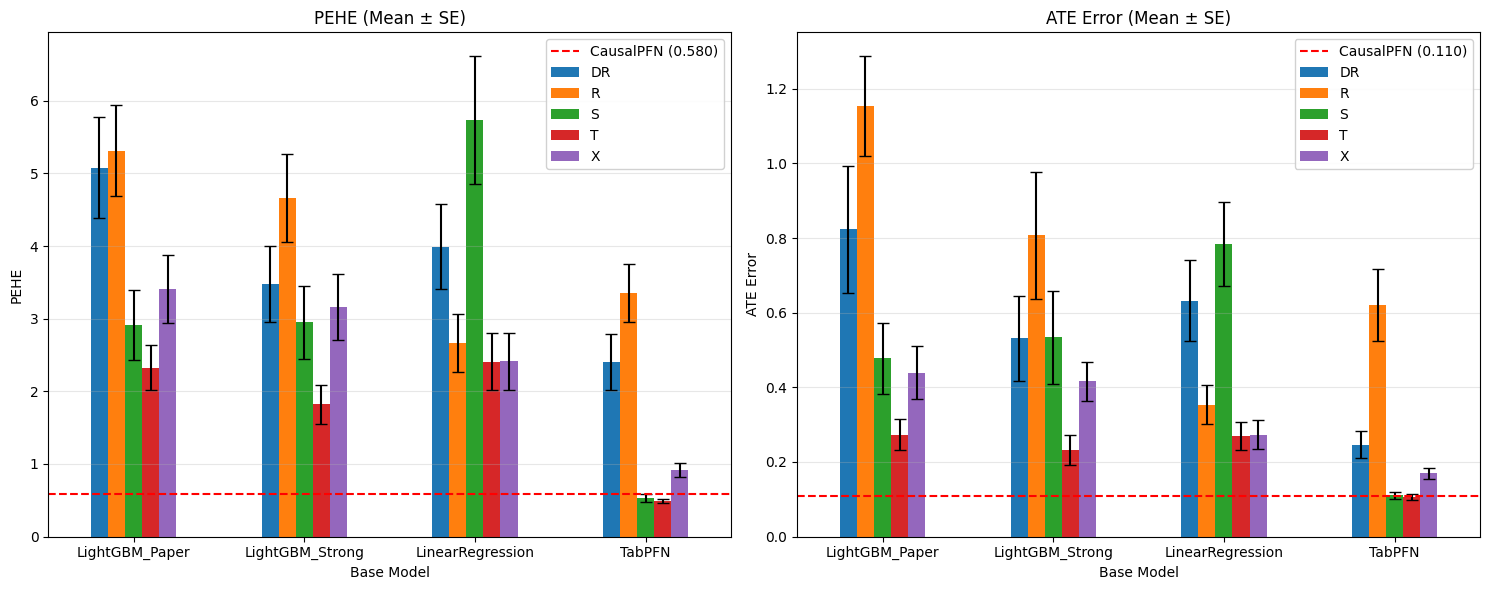

In [18]:

# Aggregate results
summary_rows = []

for meta in ['S', 'T', 'X', 'R', 'DR', 'CausalPFN']:
    # Determine which base models to iterate over
    if meta == 'CausalPFN':
        models = [meta]
    else:
        models = ['LinearRegression', 'LightGBM_Paper', 'TabPFN','LightGBM_Strong']
        
    for model in models:
        pehes = all_results[meta][model]['pehe']
        ate_errs = all_results[meta][model]['ate_error']
        
        if not pehes: # Skip if no results (e.g. if cell wasn't run)
            continue
        
        n = len(pehes)
        summary_rows.append({
            'Meta-Learner': meta,
            'Base Model': model,
            'PEHE Mean': np.mean(pehes),
            'PEHE SE': np.std(pehes) / np.sqrt(n),
            'ATE Error Mean': np.mean(ate_errs),
            'ATE Error SE': np.std(ate_errs) / np.sqrt(n)
        })

df_summary = pd.DataFrame(summary_rows)
print(df_summary.to_string(index=False))

# Export to CSV
csv_path = 'benchmark_results.csv'
df_summary.to_csv(csv_path, index=False)
print(f"\nResults exported to {csv_path}")

# Visualization — separate meta-learner bar chart from CausalPFN reference line
if not df_summary.empty:
    # Split data: meta-learners vs standalone models
    df_meta = df_summary[~df_summary['Meta-Learner'].isin(['CausalPFN'])]
    df_standalone = df_summary[df_summary['Meta-Learner'].isin(['CausalPFN'])]
    
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    metrics = ['PEHE', 'ATE Error']
    for idx, metric in enumerate(metrics):
        ax = axes[idx]
        
        if not df_meta.empty:
            plot_data = df_meta.pivot(index='Base Model', columns='Meta-Learner', values=f'{metric} Mean')
            plot_err = df_meta.pivot(index='Base Model', columns='Meta-Learner', values=f'{metric} SE')
            
            plot_data.plot(kind='bar', yerr=plot_err, ax=ax, capsize=4, rot=0, legend=False)
        
        # Add CausalPFN as horizontal reference line
        for _, row in df_standalone.iterrows():
            val = row[f'{metric} Mean']
            ax.axhline(y=val, color='red', linestyle='--', linewidth=1.5, 
                       label=f"{row['Meta-Learner']} ({val:.3f})")
        
        ax.set_title(f'{metric} (Mean \u00b1 SE)')
        ax.set_ylabel(metric)
        ax.grid(True, alpha=0.3, axis='y')
        ax.legend(loc='upper right', framealpha=0.9)
    
    plt.tight_layout()
    plt.show()
else:
    print("No results to plot.")

## 7. Leaderboard

In [19]:
# Create a ranking leaderboard for top 5 performers
print("=" * 80)
print(" " * 25 + "LEADERBOARD - TOP 5 PERFORMERS")
print("=" * 80)
print()

# Rank by PEHE (lower is better)
df_ranked_pehe = df_summary.sort_values('PEHE Mean').reset_index(drop=True)
df_ranked_pehe['Rank'] = df_ranked_pehe.index + 1

# Rank by ATE Error (lower is better)
df_ranked_ate = df_summary.sort_values('ATE Error Mean').reset_index(drop=True)
df_ranked_ate['Rank'] = df_ranked_ate.index + 1

# Display PEHE Rankings
print("PRECISION IN ESTIMATING HETEROGENEOUS EFFECTS (PEHE)")
print("   Lower is Better - Measures Individual Treatment Effect Accuracy")
print("-" * 80)
for idx, row in df_ranked_pehe.head(5).iterrows():
    rank = idx + 1
    model_name = f"{row['Meta-Learner']}-{row['Base Model']}"
    pehe_score = row['PEHE Mean']
    pehe_se = row['PEHE SE']
    
    print(f"{rank}. {model_name:30s}  PEHE: {pehe_score:6.4f} +/- {pehe_se:5.4f}")

print()
print("=" * 80)
print()

# Display ATE Error Rankings
print("AVERAGE TREATMENT EFFECT ESTIMATION (ATE Error)")
print("   Lower is Better - Measures Population-Level Treatment Effect Accuracy")
print("-" * 80)
for idx, row in df_ranked_ate.head(5).iterrows():
    rank = idx + 1
    model_name = f"{row['Meta-Learner']}-{row['Base Model']}"
    ate_score = row['ATE Error Mean']
    ate_se = row['ATE Error SE']
    
    print(f"{rank}. {model_name:30s}  ATE Error: {ate_score:6.4f} +/- {ate_se:5.4f}")

print()
print("=" * 80)
print()

# Overall winner (combining both metrics with equal weights)
# Normalize scores to 0-1 range and combine
pehe_scores = df_summary['PEHE Mean'].values
ate_scores = df_summary['ATE Error Mean'].values

pehe_normalized = (pehe_scores - pehe_scores.min()) / (pehe_scores.max() - pehe_scores.min())
ate_normalized = (ate_scores - ate_scores.min()) / (ate_scores.max() - ate_scores.min())

df_summary['Combined Score'] = (pehe_normalized + ate_normalized) / 2
df_ranked_overall = df_summary.sort_values('Combined Score').reset_index(drop=True)

print("OVERALL CHAMPION (Combined PEHE + ATE Performance)")
print("-" * 80)
winner = df_ranked_overall.iloc[0]
winner_name = f"{winner['Meta-Learner']}-{winner['Base Model']}"
print(f"Winner: {winner_name}")
print(f"   PEHE: {winner['PEHE Mean']:.4f} +/- {winner['PEHE SE']:.4f}")
print(f"   ATE Error: {winner['ATE Error Mean']:.4f} +/- {winner['ATE Error SE']:.4f}")
print()
print("=" * 80)

                         LEADERBOARD - TOP 5 PERFORMERS

PRECISION IN ESTIMATING HETEROGENEOUS EFFECTS (PEHE)
   Lower is Better - Measures Individual Treatment Effect Accuracy
--------------------------------------------------------------------------------
1. T-TabPFN                        PEHE: 0.4908 +/- 0.0331
2. S-TabPFN                        PEHE: 0.5308 +/- 0.0518
3. CausalPFN-CausalPFN             PEHE: 0.5804 +/- 0.0699
4. X-TabPFN                        PEHE: 0.9167 +/- 0.0913
5. T-LightGBM_Strong               PEHE: 1.8225 +/- 0.2690


AVERAGE TREATMENT EFFECT ESTIMATION (ATE Error)
   Lower is Better - Measures Population-Level Treatment Effect Accuracy
--------------------------------------------------------------------------------
1. T-TabPFN                        ATE Error: 0.1068 +/- 0.0077
2. CausalPFN-CausalPFN             ATE Error: 0.1101 +/- 0.0100
3. S-TabPFN                        ATE Error: 0.1101 +/- 0.0088
4. X-TabPFN                        ATE Error: 0.169

## 8. Sensitivity Analysis: Imbalance vs. Confounding

We disentangle the two main factors that make CATE estimation harder, following the decomposition principle of Bockel-Rickermann et al. (2024).

**Key insight**: IHDP provides both potential outcomes (mu0, mu1) for every unit. This means we can freely reassign T while keeping X and the potential outcomes fixed. Only the *difficulty* of the estimation problem changes — the *ground truth* τ(x) = mu1(x) − mu0(x) stays the same in every scenario.

---

### Two axes

**Axis 2 — Imbalance** (on randomized, unconfounded data):
- T ~ Bern(p), independent of X → P(T|X) = P(T) = p
- Vary p ∈ {0.50, 0.30, 0.20, 0.10, 0.05}
- Isolates the pure effect of treatment imbalance (fewer treated units to learn from)

**Axis 3 — Confounding** (on balanced data, P(T) ≈ 0.5):
- P(T=1|X) = σ(α · f̃(X)),  where f̃(X) = f(X) − mean(f(X))
- Centering ensures E[P(T=1|X)] ≈ 0.5 for all α → imbalance and confounding are decoupled
- Vary α ∈ {0, 0.5, 1.0, 2.0, 3.0}
- Isolates the pure effect of confounding / overlap violation

---

Models evaluated: **T-LightGBM** (fixed params, no re-tuning per scenario) and **T-TabPFN** (best performer from Section 4).

In [ ]:
from scipy.special import expit

# ── Scenario parameters ───────────────────────────────────────────────────────
IMBALANCE_LEVELS   = [0.5, 0.3, 0.2, 0.1, 0.05]
CONFOUNDING_ALPHAS = [0.0, 0.5, 1.0, 2.0, 3.0]

# Fixed LightGBM params for sensitivity analysis (no re-tuning per scenario)
LGBM_SENS = dict(max_depth=6, reg_lambda=1, n_estimators=500, verbose=-1)
SENS_MODELS = [
    'T-LightGBM',  'T-TabPFN',
    'DR-LightGBM', 'DR-TabPFN',
    'R-LightGBM',  'R-TabPFN',
]


# ── Helpers ───────────────────────────────────────────────────────────────────
def _lin_pred(X):
    """Linear propensity score using all 25 features.
    Coefficients (_beta) are estimated from the original IHDP treatment
    via pooled logistic regression across all 100 replications, so that
    alpha=1 approximately reproduces the observed confounding structure.
    _beta is computed in the execution cell below."""
    arr = X.values if isinstance(X, pd.DataFrame) else X
    return arr @ _beta


def _make_learner(name):
    """Return a fresh learner for the given model name.
    is_unbalance=True on all LightGBM classifiers so the propensity
    model does not collapse to majority-class under severe imbalance."""
    if name == 'T-LightGBM':
        return TLearner(models=(
            LGBMRegressor(**LGBM_SENS, random_state=42),
            LGBMRegressor(**LGBM_SENS, random_state=43)))
    elif name == 'T-TabPFN':
        return TLearner(models=(
            TabPFNRegressor(device=device),
            TabPFNRegressor(device=device)))
    elif name == 'DR-LightGBM':
        return LinearDRLearner(
            model_regression=LGBMRegressor(**LGBM_SENS, random_state=42),
            model_propensity=LGBMClassifier(**LGBM_SENS, is_unbalance=True, random_state=42),
            min_propensity=0.05)
    elif name == 'DR-TabPFN':
        return LinearDRLearner(
            model_regression=TabPFNRegressor(device=device),
            model_propensity=TabPFNClassifier(device=device),
            min_propensity=0.05)
    elif name == 'R-LightGBM':
        return NonParamDML(
            model_y=LGBMRegressor(**LGBM_SENS, random_state=42),
            model_t=LGBMClassifier(**LGBM_SENS, is_unbalance=True, random_state=42),
            model_final=LGBMRegressor(**LGBM_SENS, random_state=44),
            discrete_treatment=True)
    elif name == 'R-TabPFN':
        return NonParamDML(
            model_y=TabPFNRegressor(device=device),
            model_t=TabPFNClassifier(device=device),
            model_final=LGBMRegressor(**LGBM_SENS, random_state=44),
            discrete_treatment=True)
    raise ValueError(f"Unknown model: {name}")


# ── Scenario generators ───────────────────────────────────────────────────────
def gen_randomized(X, mu0, mu1, rng, p=0.5):
    """
    Axis 1 / 2: No confounding.
    T ~ Bern(p), independent of X.  P(T|X) = P(T) = p.
    Y = T·mu1 + (1-T)·mu0.
    """
    T = rng.binomial(1, p, len(X))
    Y = T * mu1 + (1 - T) * mu0
    return T, Y


def gen_confounded(X, mu0, mu1, rng, alpha=1.0):
    """
    Axis 3: Confounding with controlled imbalance.
    P(T=1|X) = sigma(alpha · f̃(X)),  f̃(X) = f(X) − mean(f(X)).
    Centering ensures E[P(T=1|X)] ≈ 0.5 for all alpha,
    so imbalance and confounding are decoupled.
    """
    lp = _lin_pred(X)
    lp = lp - lp.mean()          # ← KEY: P(T) ≈ 0.5 regardless of alpha
    prop = expit(alpha * lp)
    T = rng.binomial(1, prop, len(X))
    Y = T * mu1 + (1 - T) * mu0
    return T, Y


# ── Core evaluation loop ──────────────────────────────────────────────────────
def run_sensitivity_analysis(datasets, models=SENS_MODELS, n_reps=3, seed=42):
    """
    Two-axis sensitivity analysis over all IHDP replications.

    For each replication × axis × parameter × random seed:
      - Re-generates T (and Y) under the given scenario
      - Trains a T-learner on (X_train, T_train, Y_train)
      - Evaluates PEHE and ATE error on (X_test, true_ITE_test)

    The ground truth true_ITE_test = mu1_test − mu0_test is the same
    in every scenario — only the training difficulty changes.

    Parameters
    ----------
    datasets : list of dicts with keys:
        X_train, X_test, mu0_train, mu1_train, true_ITE_test
    models   : list of str — model names from SENS_MODELS
    n_reps   : int — random T-assignment seeds per replication per scenario
    seed     : int — master random seed

    Returns
    -------
    pd.DataFrame with columns:
        axis, param, model, rep, seed_rep, pehe, ate_error
    """
    rng_master = np.random.default_rng(seed)
    rows = []

    for ds in datasets:
        rep_id = ds['id']
        X_tr, X_te     = ds['X_train'], ds['X_test']
        mu0_tr, mu1_tr = ds['mu0_train'], ds['mu1_train']
        true_ite       = ds['true_ITE_test']
        print(f"  Replication {rep_id:3d}/{len(datasets)}", end='\r')

        for seed_rep in range(n_reps):
            rng = np.random.default_rng(rng_master.integers(0, int(1e9)))

            # ── Axis 2: imbalance ─────────────────────────────────────────────
            for p in IMBALANCE_LEVELS:
                T_tr, Y_tr = gen_randomized(X_tr, mu0_tr, mu1_tr, rng, p=p)
                if T_tr.sum() < 5 or (1 - T_tr).sum() < 5:
                    continue   # degenerate split — skip

                for mname in models:
                    try:
                        learner = _make_learner(mname)
                        learner.fit(Y_tr, T_tr, X=X_tr)
                        te = learner.effect(X_te, T0=0, T1=1)
                        rows.append(dict(axis='imbalance', param=p,
                                         model=mname, rep=rep_id, seed_rep=seed_rep,
                                         pehe=calculate_pehe(te, true_ite),
                                         ate_error=calculate_ate_error(te, true_ite)))
                    except Exception:
                        pass

            # ── Axis 3: confounding ───────────────────────────────────────────
            for alpha in CONFOUNDING_ALPHAS:
                T_tr, Y_tr = gen_confounded(X_tr, mu0_tr, mu1_tr, rng, alpha=alpha)
                if T_tr.sum() < 5 or (1 - T_tr).sum() < 5:
                    continue

                for mname in models:
                    try:
                        learner = _make_learner(mname)
                        learner.fit(Y_tr, T_tr, X=X_tr)
                        te = learner.effect(X_te, T0=0, T1=1)
                        rows.append(dict(axis='confounding', param=alpha,
                                         model=mname, rep=rep_id, seed_rep=seed_rep,
                                         pehe=calculate_pehe(te, true_ite),
                                         ate_error=calculate_ate_error(te, true_ite)))
                    except Exception:
                        pass

    print(f"\nDone — {len(rows)} rows collected.")
    return pd.DataFrame(rows)


# ── Visualization ─────────────────────────────────────────────────────────────
def plot_sensitivity(df, save_path='sensitivity_analysis.png'):
    """
    2×2 grid: rows = metrics (PEHE, ATE error), cols = axes (imbalance, confounding).
    """
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    axis_meta = {
        'imbalance':   ('P(T=1)  [0.5 = balanced]',   'Imbalance  [T ⊥ X,  P(T) varies]'),
        'confounding': ('α  [0 = no confounding]',     'Confounding  [P(T) ≈ 0.5,  α varies]'),
    }

    for col, axis_key in enumerate(['imbalance', 'confounding']):
        df_ax  = df[df['axis'] == axis_key]
        xlabel, title_suffix = axis_meta[axis_key]

        for row, metric in enumerate(['pehe', 'ate_error']):
            ax = axes[row][col]
            for model in sorted(df_ax['model'].unique()):
                grp   = df_ax[df_ax['model'] == model].groupby('param')[metric]
                means = grp.mean()
                sems  = grp.sem()
                ax.errorbar(means.index, means.values, yerr=sems.values,
                            marker='o', capsize=4, linewidth=1.8, label=model)

            ax.set_xlabel(xlabel)
            ax.set_ylabel(metric.upper())
            ax.set_title(f'{metric.upper()} — {title_suffix}')
            ax.legend(framealpha=0.9)
            ax.grid(True, alpha=0.3)

    plt.suptitle('Sensitivity Analysis: Imbalance vs. Confounding', y=1.01, fontsize=13)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Figure saved → {save_path}")

In [ ]:
# ── Load IHDP replications with potential outcomes ────────────────────────────
# Self-contained: re-loads the npz files directly so this section runs
# independently without needing to rerun the 8-hour Sections 4–5.

_n_datasets    = 100
_feature_names = [f"x{j}" for j in range(25)]
_train_data    = np.load('IHDP/ihdp_npci_1-100.train.npz')
_test_data     = np.load('IHDP/ihdp_npci_1-100.test.npz')

# ── Estimate confounding direction from original treatment ────────────────
# Pool all 100 replications and fit logistic regression of T on X.
# The resulting _beta defines the direction of confounding used in
# gen_confounded; alpha=1 then roughly recovers the observed propensity.
_X_pool  = _train_data['x'].transpose(2, 0, 1).reshape(-1, 25)
_T_pool  = _train_data['t'].T.reshape(-1)
_lr_prop = LogisticRegression(C=1.0, max_iter=1000, random_state=42)
_lr_prop.fit(_X_pool, _T_pool)
_beta    = _lr_prop.coef_[0]   # shape (25,) — used by _lin_pred
print(f'Propensity direction estimated from pooled IHDP data (LR across all 100 reps).')
del _X_pool, _T_pool, _lr_prop  # free memory

sens_datasets = []
for i in range(_n_datasets):
    sens_datasets.append({
        'id':            i + 1,
        'X_train':       pd.DataFrame(_train_data['x'][:, :, i], columns=_feature_names),
        'X_test':        pd.DataFrame(_test_data['x'][:, :, i],  columns=_feature_names),
        'mu0_train':     _train_data['mu0'][:, i],
        'mu1_train':     _train_data['mu1'][:, i],
        'true_ITE_test': _test_data['mu1'][:, i] - _test_data['mu0'][:, i],
    })

print(f"Ready: {len(sens_datasets)} IHDP replications with potential outcomes.\n")

# ── Run ────────────────────────────────────────────────────────────────────────
# n_reps=3: each IHDP replication is evaluated with 3 independent T-assignments
# per scenario → 100 × 3 = 300 samples per scenario point.
print("Running sensitivity analysis (n_reps=3 per replication per scenario)...")
sens_df = run_sensitivity_analysis(sens_datasets, models=SENS_MODELS, n_reps=3, seed=42)
sens_df.to_csv('sensitivity_results_ihdp.csv', index=False)
print(f"Saved → sensitivity_results_ihdp.csv  ({len(sens_df)} rows)\n")

# ── Summary table ──────────────────────────────────────────────────────────────
print("── Imbalance axis (mean over all replications & seeds) ─────────────────")
print(sens_df[sens_df['axis'] == 'imbalance']
      .groupby(['param', 'model'])[['pehe', 'ate_error']]
      .mean().round(4).to_string())

print("\n── Confounding axis ────────────────────────────────────────────────────")
print(sens_df[sens_df['axis'] == 'confounding']
      .groupby(['param', 'model'])[['pehe', 'ate_error']]
      .mean().round(4).to_string())

# ── Plot ───────────────────────────────────────────────────────────────────────
plot_sensitivity(sens_df)